In [55]:
from pathlib import Path
from platform import python_version
import importlib
import logging
import sys
import os

logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")
logger.info("Interpreting with python {}".format(python_version()))
# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
data_dir = module_dir / "data"
logger.info(f"Module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
    logger.info("Module path inserted into system path, ready to use")
else:
    logger.info("Module path already inserted into system paths")

# Temp solution to load as module
try:
    from model import markov_chain as mc
    from model import probabilistic_analysis as psa
    from model import visualization
    from model import constants
    from model import utils

    # Force to update module
    importlib.reload(mc)
    importlib.reload(psa)
    importlib.reload(visualization)
    importlib.reload(constants)
    importlib.reload(utils)
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: Interpreting with python 3.13.7
INFO: Module directory: /home/mohammad/projects/Thesis/hemophilia
INFO: Module path already inserted into system paths


In [56]:
import numpy as np


logger.info(
    """\n
    Simplified Final Markov Model Structure

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------
"""
)

# INPUTS
sobol_sample_size = 32  # simulated sample final count follows: N * (D + 2)
n_cycles = constants.SHORT_TERM_CYCLE_COUNTS
ssp = constants.SHORT_SIMULATION_START_AGE_IN_WEEK  # simulation starting point
estate = constants.START_STATE  # Entrance state
stats = constants.STATES

logger.info(
    f"""
    Model initialized with:
    - Base sample size: {sobol_sample_size}
    - Simulation steps: {n_cycles} ({n_cycles / constants.WOY} Years)
    - Simulation starting point: {ssp} ({ssp / constants.WOY} YO)
    """
)

chains = []
chain_main = mc.Chain(
    name="main",
    states=stats,
    matrix=np.eye(N=len(stats), M=len(stats), dtype=np.float64),
)
chains.append(chain_main)

INFO: 

    Simplified Final Markov Model Structure

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------

INFO: 
    Model initialized with:
    - Base sample size: 32
    - Simulation st

INFO: Sampling ABR values took 0.12 seconds
INFO: Generated data length: 704


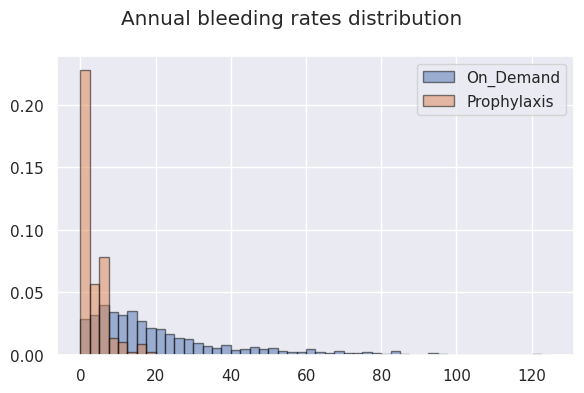

In [57]:
# Short term simulation
from time import time
import matplotlib.pyplot as plt
import seaborn as sns

run_time = time()
# Note: For the sake of statistical comparison n_samples should be in same size over different population in each treatment arms
on_demand_sampled_abr = psa.generate_population_abrs(
    treatment=psa.Treatment.ON_DEMAND, n_samples=sobol_sample_size, visualize=False
)
prophylaxis_sampled_abr = psa.generate_population_abrs(
    treatment=psa.Treatment.PROPHYLAXIS, n_samples=sobol_sample_size, visualize=False
)
exc_time = round((time() - run_time), 2)
logger.info(f"Sampling ABR values took {exc_time} seconds")
logger.info(f"Generated data length: {len(on_demand_sampled_abr)}")

# Drawing population ABR distribution
plt.figure(figsize=(6, 4))
plt.suptitle("Annual bleeding rates distribution")
on_demand_hist = plt.hist(
    on_demand_sampled_abr,
    50,
    range=(0, 125),
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="On_Demand",
)
prophylaxis_hist = plt.hist(
    prophylaxis_sampled_abr,
    50,
    range=(0, 125),
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Prophylaxis",
)
plt.legend()
plt.tight_layout()

INFO: Patients average weight: 24.27 kg


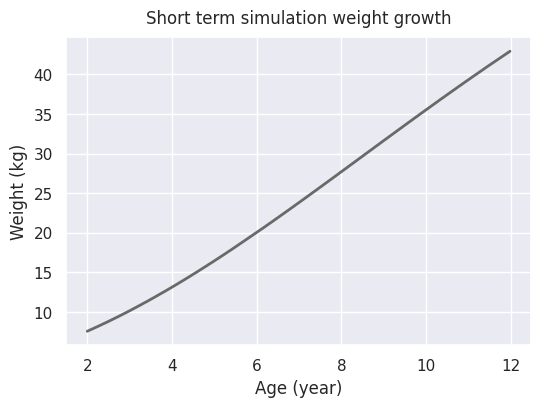

In [58]:
weights = [utils.cal_body_weight(n, b=ssp) for n in range(n_cycles)]
pairs: dict[int, float] = {(i + ssp): weight for i, weight in enumerate(weights)}
average_weight = np.mean(list(pairs.values()))

logger.info(f"Patients average weight: {round(average_weight, 2)} kg")

# Drawing patient weight growth graph
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
X = np.array(list(pairs.keys()))
Y = np.array(list(pairs.values()))
ax.plot(X / constants.WOY, Y, color="dimgray", linestyle="-", linewidth=2)
text = ax.set_title("Short term simulation weight growth", pad=10)
y_text = ax.set_ylabel("Weight (kg)")
x_text = ax.set_xlabel("Age (year)")

In [70]:
markov = mc.MarkovChains(
    chains=chains,
    entrance="Healthy",
    entrance_chain="main",
    steps=n_cycles,
    conditions=None,
)
logger.info(f"Starting simulations for {n_cycles} steps (weeks)")
on_demand_results = psa.parallelize_markov_chain(
    simulation_name="on_demand",
    worker_inputs=[
        psa.HemophiliaInputs(
            treatment=psa.Treatment.ON_DEMAND,
            abr=abr,
            ajbr=None,
            wbr=None,
            webr=None,
            wjbr=None,
        )
        for abr in on_demand_sampled_abr
    ],
    worker_func=psa.worker_function,
    markov_chain=markov,
)
prophylaxis_results = psa.parallelize_markov_chain(
    simulation_name="prophylaxis",
    worker_inputs=[
        psa.HemophiliaInputs(
            treatment=psa.Treatment.PROPHYLAXIS,
            abr=abr,
            ajbr=None,
            wbr=None,
            webr=None,
            wjbr=None,
        )
        for abr in prophylaxis_sampled_abr
    ],
    worker_func=psa.worker_function,
    markov_chain=markov,
)

INFO: Starting simulations for 520 steps (weeks)


In [71]:
# Unwrap input outputs from results
on_demand_inputs, on_demand_outputs = on_demand_results
prophylaxis_inputs, prophylaxis_outputs = prophylaxis_results

In [72]:
SAMPLE_SIZE = len(on_demand_sampled_abr)
logger.info(f"{SAMPLE_SIZE:,} data generated to work with")

cols = list(psa.HemophiliaOutputs.model_fields.keys())
cols.insert(0, "regimes")
cols.insert(1, "input_abr")

for key in ["is_arthropathy", "is_dead", "weights", "mean_weight", "person_year"]:
    cols.append(key)

logger.info("Dataframe Columns: \n {}".format(cols).replace(",", ",\n"))

INFO: 704 data generated to work with
INFO: Dataframe Columns: 
 ['regimes',
 'input_abr',
 'initial_state',
 'final_state',
 'steps',
 'path',
 'factor_consumption',
 'factor_costs',
 'annual_factor_consumption',
 'annual_factor_costs',
 'hemarthrosis',
 'qaly',
 'abr',
 'is_arthropathy',
 'is_dead',
 'weights',
 'mean_weight',
 'person_year']


In [74]:
import pandas as pd
import numpy as np


def truncate_weights_at_death(sequences: list["str"]):
    death_indices = [
        i
        for i, state in enumerate(sequences)
        if state
        and any(
            "death" in str(s).lower()
            for s in (state if isinstance(state, (list, tuple)) else [state])
        )
    ]

    if death_indices:
        # Use the first death occurrence
        death_index = death_indices[0]
        return weights[: death_index + 1]  # Include the death state

    # If no death found, return full weights
    return weights


run_time = time()
on_demand_df = pd.DataFrame(
    columns=cols,
    data={
        "regimes": "on_demand",
        "initial_state": [op.initial_state for op in on_demand_outputs],
        "final_state": [op.final_state for op in on_demand_outputs],
        "steps": [op.steps for op in on_demand_outputs],
        "input_abr": [op["abr"] for op in on_demand_inputs],
        "abr": [op.abr for op in on_demand_outputs],
        "hemarthrosis": [op.hemarthrosis for op in on_demand_outputs],
        "factor_consumption": [op.factor_consumption for op in on_demand_outputs],
        "qaly": [op.qaly for op in on_demand_outputs],
        "factor_costs": [op.factor_costs for op in on_demand_outputs],
        "annual_factor_consumption": [
            op.annual_factor_consumption for op in on_demand_outputs
        ],
        "annual_factor_costs": [op.annual_factor_costs for op in on_demand_outputs],
        "is_arthropathy": [
            True if "Arthropathy" in op.path else False for op in on_demand_outputs
        ],
        "is_dead": [True if "Death" in op.path else False for op in on_demand_outputs],
        "path": [op.path for op in on_demand_outputs],
        "weights": [truncate_weights_at_death(op.path) for op in on_demand_outputs],
    },
)
on_demand_df["mean_weight"] = on_demand_df["weights"].apply(
    lambda x: round(np.array(x).mean(), 2)
)
on_demand_df["person_year"] = on_demand_df["weights"].apply(
    lambda x: round(len(x) / constants.WOY, 2)
)
exc_time = round((time() - run_time), 2)
logger.info(f"Loading on_demand data with pandas took {exc_time} seconds")

run_time = time()
prophylaxis_df = pd.DataFrame(
    data={
        "regimes": "prophylaxis",
        "input_abr": [op["abr"] for op in prophylaxis_inputs],
        "initial_state": [op.initial_state for op in prophylaxis_outputs],
        "final_state": [op.final_state for op in prophylaxis_outputs],
        "steps": [op.steps for op in prophylaxis_outputs],
        "abr": [op.abr for op in prophylaxis_outputs],
        "hemarthrosis": [op.hemarthrosis for op in prophylaxis_outputs],
        "factor_consumption": [op.factor_consumption for op in prophylaxis_outputs],
        "qaly": [op.qaly for op in prophylaxis_outputs],
        "factor_costs": [op.factor_costs for op in prophylaxis_outputs],
        "annual_factor_consumption": [
            op.annual_factor_consumption for op in prophylaxis_outputs
        ],
        "annual_factor_costs": [op.annual_factor_costs for op in prophylaxis_outputs],
        "is_arthropathy": [
            True if "Arthropathy" in op.path else False for op in prophylaxis_outputs
        ],
        "is_dead": [
            True if "Death" in op.path else False for op in prophylaxis_outputs
        ],
        "path": [op.path for op in prophylaxis_outputs],
        "weights": [truncate_weights_at_death(op.path) for op in prophylaxis_outputs],
    },
    columns=cols,
)
prophylaxis_df["mean_weight"] = prophylaxis_df["weights"].apply(
    lambda x: round(np.array(x).mean(), 2)
)
prophylaxis_df["person_year"] = prophylaxis_df["weights"].apply(
    lambda x: round(len(x) / constants.WOY, 2)
)
exc_time = round((time() - run_time), 2)
logger.info(f"loading prophylaxis data with pandas took {exc_time} seconds")

df_raw = pd.concat([on_demand_df, prophylaxis_df])

df = df_raw.drop(columns=["initial_state", "steps", "path", "weights"])
df = df.apply(lambda x: round(x, 2) if pd.api.types.is_numeric_dtype(x) else x)
df.head(n=5)

INFO: Loading on_demand data with pandas took 0.35 seconds
INFO: loading prophylaxis data with pandas took 0.32 seconds


,regimes,input_abr,final_state,factor_consumption,factor_costs,annual_factor_consumption,annual_factor_costs,hemarthrosis,qaly,abr,is_arthropathy,is_dead,mean_weight,person_year
0,on_demand,1.92,Healthy,31283.0,2125.45,3128.3,212.55,1.2,8.77,1.6,False,False,24.27,10.0
1,on_demand,18.53,Healthy,369313.0,25092.11,36931.3,2509.21,12.1,7.36,16.3,False,False,24.27,10.0
2,on_demand,1.92,Healthy,31283.0,2125.45,3128.3,212.55,1.2,8.77,1.6,False,False,24.27,10.0
3,on_demand,11.04,Healthy,224805.0,15273.85,22480.5,1527.38,7.5,7.85,9.1,False,False,24.27,10.0
4,on_demand,10.24,Healthy,194819.0,13236.52,19481.9,1323.65,7.4,7.89,8.3,False,False,24.27,10.0


In [99]:
df_alive = df[df["is_dead"] == False]  # noqa: E712
under_abr = df_alive[df_alive["input_abr"] > df_alive["abr"]]
over_abr = df_alive[df_alive["input_abr"] < df_alive["abr"]]
# Sums
print(
    f"""
      Sum of model input bleeding events for alive patients: {round(df_alive["input_abr"].sum()):,}
      Sum of bleeding events simulated for alive patients: {round(df_alive["abr"].sum()):,}
      Similarity {round((df_alive["abr"].sum() / df_alive["input_abr"].sum()), 2) * 100}%

      Count of alive dataframe rows: {df_alive["regimes"].count()}
      Count of simulations over model input abr {over_abr["input_abr"].count()}
      Count of simulations under model input abr {under_abr["abr"].count()}
      
      # NOTE:
      Probability the population who had over bleeds in on_demand therapy had more death events so only the under bleed patients survived
      """
)

# Medians
print(
    f"""
      Median of model input bleeding events for alive patients: {round(df_alive["input_abr"].median()):,}
      Median of bleeding events simulated for alive patients: {round(df_alive["abr"].median()):,}
      Similarity {round((df_alive["abr"].median() / df_alive["input_abr"].median()), 2) * 100}%
      """
)

# TODO:
# Patients under bleed (?)


      Sum of model input bleeding events for alive patients: 10,292
      Sum of bleeding events simulated for alive patients: 9,007
      Similarity 88.0%

      Count of alive dataframe rows: 1105
      Count of simulations over model input abr 267
      Count of simulations under model input abr 808
      
      # NOTE:
      Probability the population who had over bleeds in on_demand therapy had more death events so only the under bleed patients survived
      

      Median of model input bleeding events for alive patients: 5
      Median of bleeding events simulated for alive patients: 5
      Similarity 89.0%
      


In [ ]:
# ---- Debug cell ----
debug = False

# Graphs stores at outputs/figures/transitions
if debug:
    # on_demand simulation transition matrix graph
    for i, on_demand_inputs in enumerate(np.random.choice(on_demand_inputs, size=5)):
        chains = on_demand_inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        visualization.visualize_transition_matrix(
            matrix=primary_matrix,
            states=stats,
            title=f"on-demand-primary-{int(round(on_demand_inputs['abr'],0))}-{int(round(on_demand_inputs['ajbr'], 0))}",
        )
        visualization.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=states_1,
            title=f"on-demand-secondary-{int(round(on_demand_inputs['abr'],0))}-{int(round(on_demand_inputs['ajbr'], 0))}",
        )
    # prophylaxis simulation transition matrix graph
    for i, on_demand_inputs in enumerate(np.random.choice(prophylaxis_inputs, size=5)):
        chains = on_demand_inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        visualization.visualize_transition_matrix(
            matrix=primary_matrix,
            states=stats,
            title=f"prophylaxis-primary-{int(round(on_demand_inputs['abr'],0))}-{int(round(on_demand_inputs['ajbr'], 0))}",
        )
        visualization.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=states_1,
            title=f"prophylaxis-secondary-{int(round(on_demand_inputs['abr'],0))}-{int(round(on_demand_inputs['ajbr'], 0))}",
        )

In [ ]:
SIM_YEARS = int(n_cycles / constants.WOY)
DC = round((prophylaxis_df["costs"].mean() - on_demand_df["costs"].mean()), 2)  # per patient
DQ = round((prophylaxis_df["qalys"].mean() - on_demand_df["qalys"].mean()), 2)  # per patient
DC_TOTAL = round(prophylaxis_df["costs"].sum() - on_demand_df["costs"].sum(), 2)
DQ_TOTAL = round(prophylaxis_df["qalys"].sum() - on_demand_df["qalys"].sum(), 2)
# annual costs gained per patient
DC_ANNUAL = round(DC / (n_cycles / constants.WOY), 2)
ICER = DC_TOTAL / DQ_TOTAL
ICER_ANNUAL = round(ICER / (n_cycles / constants.WOY), 2)
LYG_TOTAL = round(prophylaxis_df["person_year"].sum() - on_demand_df["person_year"].sum(), 2)
ICER_LTG = DC_TOTAL / LYG_TOTAL


# Net monetary benefits
NMB = round((constants.WTP_THRESHOLD * SIM_YEARS * (DQ)) - (DC), 2)
# TODO:
# - Number of died patients are not rational, tune the model with accurate rate
# - Make sure the transitioning probability to arthropathy is valid
logger.info(
    f"""
    [Short Term]
    Simulation results for {int(n_cycles/constants.WOY)} Years ({int(ssp/52)} - {int((ssp + n_cycles)/52)}) | {SAMPLE_SIZE} samples included
    Number of simulations transitioned to chronic arthropathy: -> On Demand: {on_demand_df["is_arthropathy"].sum()} - Prophylaxis: {prophylaxis_df["is_arthropathy"].sum()}
    Percentage of normal joints: On Demand: -> {round(1 - (on_demand_df['is_arthropathy'].sum()/SAMPLE_SIZE), 2)}% - Prophylaxis: {round(1 - (prophylaxis_df['is_arthropathy'].sum()/SAMPLE_SIZE), 2)}%
    Number of patients died during simulation period: -> On Demand: {on_demand_df["is_dead"].sum()} - Prophylaxis: {prophylaxis_df['is_dead'].sum()}
    Mortality rate (deaths per 100 person-years): -> On Demand: {round(on_demand_df["is_dead"].sum()/on_demand_df['person_year'].sum() * 100, 2)} - Prophylaxis: {round(prophylaxis_df['is_dead'].sum()/prophylaxis_df['person_year'].sum() * 100, 2)}
    Life year gained: {LYG_TOTAL} years, per person {round(LYG_TOTAL / SAMPLE_SIZE, 2)} years
    
    [Model outputs]
    Annual bleeding rate:
    - On Demand: Mean (std) {int(on_demand_df['bleeds'].mean())} ({int(on_demand_df['bleeds'].std())}), Median {int(on_demand_df['bleeds'].median())}
    - Prophylaxis : Mean (std) {int(prophylaxis_df['bleeds'].mean())} ({int(prophylaxis_df['bleeds'].std())}), Median {int(prophylaxis_df['bleeds'].median())}
    Note: prophylaxis on average reduces ABR about {1 - round(on_demand_df['bleeds'].mean()/ prophylaxis_df['bleeds'].mean()/100, 2)}%
    
    Total factor consumption:
    - On Demand: {int(on_demand_df['factors'].mean())} ({int(on_demand_df['factors'].std())}) IU
    - Prophylaxis: {int(prophylaxis_df['factors'].mean())} ({int(prophylaxis_df['factors'].std())}) IU
    Note: consumptions increased by {round(prophylaxis_df['factors'].mean() / on_demand_df['factors'].mean(), 2)} folds
    
    Annual factor consumption:
    - On Demand: {int(on_demand_df['annual_factors'].mean())} ({int(on_demand_df['annual_factors'].std())}) IU
    - Prophylaxis: {int(prophylaxis_df['annual_factors'].mean())} ({int(prophylaxis_df['annual_factors'].std())}) IU
    
    Annual factor consumption per kg:
    - On Demand: {int(on_demand_df['annual_factors'].mean() / on_demand_df['mean_weight'].mean())} IU
    - Prophylaxis: {int(prophylaxis_df['annual_factors'].mean() / prophylaxis_df['mean_weight'].mean())} IU
    
    Annual factor costs per kg:
    - On Demand: ${int(on_demand_df['annual_costs'].mean() / on_demand_df['mean_weight'].mean()):,}
    - Prophylaxis: ${int(prophylaxis_df['annual_costs'].mean() / prophylaxis_df['mean_weight'].mean()):,}
    
    Annual burden of disease for {SAMPLE_SIZE} patients (Factor VIII only):
    - On Demand: ${int(on_demand_df['annual_costs'].sum()):,}
    - Prophylaxis: ${int(prophylaxis_df['annual_costs'].sum()):,}
    
    Quality adjusted life year:
    - On Demand: Mean (std) {round(on_demand_df['qalys'].mean(), 2)}, ({round(on_demand_df['qalys'].std(), 2)}), Median {round(on_demand_df['qalys'].median(), 2)}
    - Prophylaxis: Mean (std) {round(prophylaxis_df['qalys'].mean(), 2)}, ({round(prophylaxis_df['qalys'].std(), 2)}) | Median {round(prophylaxis_df['qalys'].median(), 2)}
    
    Conclusions:
    {DQ} qaly gained with ${DC:,} increase in cost of treatment
    Incremental cost effectiveness ratio: ${int(ICER):,} | ICER LYG: ${int(ICER_LTG):,}
    Willingness to pay threshold: ${round(constants.WTP_THRESHOLD, 2):,} {'>' if constants.WTP_THRESHOLD > ICER_ANNUAL else '<'} ${ICER_ANNUAL:,}
    Net monetary benefit: ${int(NMB):,} (per patient treated)
    
    CUA: Intervention was{' ' if NMB > 0 else ' not '}cost effective
    """
)

In [ ]:
from matplotlib.gridspec import GridSpec

logger.info(
    """
    Bootstrapping model outputs to calculate ICER IQR and SD
    """
)
ICERS = []
BOOTS_ITER = 5000
run_time = time()
for _ in range(BOOTS_ITER):
    on_demand_results = on_demand_df.sample(n=SAMPLE_SIZE, replace=True)
    pro = prophylaxis_df.sample(n=SAMPLE_SIZE, replace=True)
    dc = pro["costs"].sum() - on_demand_results["costs"].sum()
    dq = pro["qalys"].sum() - on_demand_results["qalys"].sum()
    if np.isfinite(dc) and np.isfinite(dq) and dq != 0:
        ICERS.append(dc / dq)
logger.info(
    f"Bootstrapping with {BOOTS_ITER} iterations took {round(time() - run_time, 2)} seconds"
)

ICERS = np.array(ICERS)
pairs = {i: y for i, y in enumerate(ICERS)}
X = list(pairs.keys())
Y = list(pairs.values())

sns.set_theme(style='white')
fig = plt.figure(figsize=(16, 8))

gs = GridSpec(2, 2, width_ratios=(2, 1), height_ratios=(1, 1))
ax1 = fig.add_subplot(gs[:, :-1])
ax2 = fig.add_subplot(gs[-1, -1])
ax1.scatter(X, Y, s=5)
ax2.hist(Y, color="gray", density=True, edgecolor="black")


Q1 = np.percentile(ICERS, 25).astype(float)
Q2 = np.percentile(ICERS, 50).astype(float)
Q3 = np.percentile(ICERS, 75).astype(float)
ICERS_MEAN = ICERS.mean()

ax1.axhline(Q1, color="black", linewidth=2, label=f"Q1: ${int(Q1)/SIM_YEARS:,} Annual")
ax1.axhline(Q2, color="black", linewidth=2, label=f"Q2: ${int(Q2/SIM_YEARS):,} Annual")
ax1.axhline(Q3, color="black", linewidth=2, label=f"Q3: ${int(Q3/SIM_YEARS):,} Annual")
ax1.axhline(
    ICERS_MEAN,
    color="purple",
    linewidth=2,
    label=f"Mean: ${int(ICERS_MEAN/SIM_YEARS):,} Annual",
)
ax1.set_xlim(left=0, right=ICERS.shape[0])
ax1.set_ylabel('Incremental costs')
ax1.set_xlabel('Iteration')
ax1.legend()
fig.suptitle('ICER Bootstrap')
fig.tight_layout()

logger.info(
    f"""
    IQR: ${(Q3 - Q1):.2f}
    """
)

In [ ]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 1.5
X = np.linspace(start=0, stop=max_threshold, num=1000)

Y = []

for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(ICERS / SIM_YEARS <= threshold) # type: ignore
    ratio = cost_effective_count / len(ICERS)
    Y.append(ratio)
    
icer_ratio = np.sum(ICERS / SIM_YEARS <= constants.WTP_THRESHOLD) / len(ICERS) # type: ignore
# Create the plot
sns.set_theme(style='white')
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(x=constants.WTP_THRESHOLD, color='gray', label=f"IR WTP Threshold ${int(constants.WTP_THRESHOLD)}")
ax.scatter(x=constants.WTP_THRESHOLD, y=icer_ratio, color='red', s=50, label=f"Point estimate ratio: {round(icer_ratio, 2)}%")
ax.set_xlabel('Willingness-to-Pay Threshold')
ax.set_ylabel('Proportion of Cost-Effective Interventions')
ax.set_title('Cost-Effectiveness Acceptability Curve')
ax.set_xlim(12000, max_threshold)
ax.set_ylim(-0.1, 1.1)
ax.legend()
fig.tight_layout()

In [ ]:
# sns.set_theme(style="darkgrid", rc={"axes.spines.right": False, "axes.spines.top": False})
sns.set_theme(style='white')
run_time = time()
dc = prophylaxis_df["costs"].to_numpy() - on_demand_df["costs"].to_numpy()
dq = prophylaxis_df["qalys"].to_numpy() - on_demand_df["qalys"].to_numpy()

valid_mask = np.isfinite(dq) & np.isfinite(dc) & (dq != 0)

ICERS = dc[valid_mask] / dq[valid_mask]

logger.info(f"ICER calculation took: {round(time() - run_time, 2)} seconds")

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 1))

ax1 = fig.add_subplot(gs[:, :-1])
ax2 = fig.add_subplot(gs[:, -1])

ax1.scatter(x=[i for i in range(ICERS.shape[0])], y=ICERS, s=5)
ax1.set_ylabel('Incremental costs')
ax1.set_xlabel('Iteration number over simulation results')

Q1 = np.percentile(ICERS, 25).astype(float)
Q2 = np.percentile(ICERS, 50).astype(float)
Q3 = np.percentile(ICERS, 75).astype(float)

P5 = np.percentile(ICERS, 5).astype(float)
P95 = np.percentile(ICERS, 95).astype(float)
TRUNC_ICERS = ICERS[(ICERS >= P5) & (ICERS <= P95)]
ax2.hist(TRUNC_ICERS, bins=50, color="gray", orientation="horizontal")
ax2.set_ylim(bottom=P5, top=P95)

ax1.axhline(
    Q1,
    color="black",
    linewidth=2,
)
ax1.axhline(
    Q2,
    color="purple",
    linewidth=2,
)
ax1.axhline(Q3, color="black", linewidth=2)
ax1.set_xlim(left=0, right=ICERS.shape[0])
ax1.set_ylim(bottom=P5, top=P95)
fig.legend(
    [
        "ICER",
        f"Q1: ${int(Q1 / SIM_YEARS):,} Annual",
        f"Q2: ${int(Q2 / SIM_YEARS):,} Annual",
        f"Q3: ${int(Q3 / SIM_YEARS):,} Annual",
    ],
    loc="upper center",
    bbox_to_anchor=(0.62, 0.94),
)
fig.tight_layout()

In [ ]:
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.scatter(x=dq, y=dc / SIM_YEARS, s=10, edgecolor="#738EE0", color="#BACAED")
ax.axvline(x=0, color="gray")
ax.axhline(y=0, color="gray")
ax.axline(
    (0, 0),
    slope=constants.WTP_THRESHOLD,
    color="#4A4A4A",
    linestyle="--",
    linewidth=2,
    label = f"WTP Annual: ${int(constants.WTP_THRESHOLD)}"
)
fig.legend(loc='upper left', bbox_to_anchor=(0.10, 0.93))
fig.tight_layout()

In [ ]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 1.5
X = np.linspace(start=0, stop=max_threshold, num=1000)

Y = []
for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(ICERS / SIM_YEARS <= threshold)
    ratio = cost_effective_count / len(ICERS)
    Y.append(ratio)
icer_ratio = np.sum(ICERS / SIM_YEARS <= constants.WTP_THRESHOLD) / len(ICERS)
# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(x=constants.WTP_THRESHOLD, color='gray', label=f"IR WTP Threshold ${int(constants.WTP_THRESHOLD)}")
ax.scatter(x=constants.WTP_THRESHOLD, y=icer_ratio, color='red', s=50, label=f"Point estimate ratio: {round(icer_ratio, 2)}%")
ax.set_xlabel('Willingness-to-Pay Threshold')
ax.set_ylabel('Proportion of Cost-Effective Interventions')
ax.set_title('Cost-Effectiveness Acceptability Curve')
ax.set_xlim(0, max_threshold)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(df_raw, x='qalys', y='costs', hue='regimes', s=10)
plt.tight_layout()

In [ ]:
# Value to report:
# Report no. of factor viii infusions [ ]
# Report annual cost of factor viii / kg [ ]
# Report annual joint hemorrhages [ ]
# Budget impact [ ]
# Onset of arthropathy [ ]
# Number of treated bleeds [ ]
# Burden of disease [√]
# Report no. of factor viii unit infused [√]
# Report no. of factor viii unit infused per kg [√]
# Report annual bleeding rate [√]
# Report quality adjusted life year [√]
# Report Incremental cost effectiveness ratio [√]
# Report Net monetary benefit [√]